In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
pd.options.display.max_rows

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold, cross_val_score

In [11]:
cars = sns.load_dataset('mpg')
cars.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
5,15.0,8,429.0,198.0,4341,10.0,70,usa,ford galaxie 500
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
9,15.0,8,390.0,190.0,3850,8.5,70,usa,amc ambassador dpl


In [12]:
cars.dropna(inplace=True)

In [13]:
X = cars.drop(columns = ['origin', 'name', 'mpg'])
y = cars['mpg']
 
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state = 42
                                                   )


model = LinearRegression()
model = model.fit(X_train, y_train)

y_predicted = model.predict(X_test)
y_estimated = model.predict(X_train)

print('Train r2 =', model.score(X_train, y_train))
print('Test r2 =', model.score(X_test, y_test))

print('MAE_test =', mean_absolute_error(y_test, y_predicted))
print('RMSE_test =', root_mean_squared_error(y_test, y_predicted))

print('MAE_train =', mean_absolute_error(y_train, y_estimated))
print('RMSE_train =', root_mean_squared_error(y_train, y_estimated))

print(model.coef_)
 

Train r2 = 0.8107227953093896
Test r2 = 0.7942349075428591
MAE_test = 2.503860089776125
RMSE_test = 3.2407360783342574
MAE_train = 2.6691759304817215
RMSE_train = 3.4559142294242142
[-0.116173    0.00101347 -0.00227634 -0.00656101  0.06173551  0.76063644]


In [14]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

def cross_val_results(X, y, model = LinearRegression(), cv=5, scoring = 'r2'):
    scores = cross_val_score(model, X, y, cv=5, scoring = 'r2')
 
    print(f"Scores: {scores}")
    print(f"Mean: {scores.mean()}")
    print(f"Std: {scores.std()}")
    return scores

In [15]:
cross_val_results(X, y, model = LinearRegression(), cv=5, scoring = 'r2')

Scores: [0.53808013 0.67523294 0.81275835 0.68577017 0.14394899]
Mean: 0.5711581174835774
Std: 0.23062521817669548


array([0.53808013, 0.67523294, 0.81275835, 0.68577017, 0.14394899])

###### Task 1: Convert the categorical columns to dummy columns and train a new model on your enriched dataset. Compare the performance of this model with the previous one.

In [16]:
cars.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [20]:
cars['origin'].value_counts()


origin
usa       245
japan      79
europe     68
Name: count, dtype: int64

In [23]:
dummies_origin = pd.get_dummies(cars['origin'], dtype=int, drop_first = True)
dummies_origin.head()

,japan,usa
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [24]:
cars_dummies = pd.concat([cars, dummies_origin], axis = 1)
cars_dummies.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,japan,usa
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,0,1
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,0,1
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,0,1
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,0,1
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,0,1


In [46]:
X = cars_dummies.drop(columns = ['origin', 'name', 'acceleration', 'model_year', 'weight'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

model = LinearRegression()
model = model.fit(X_train, y_train)

y_predicted = model.predict(X_test)
y_estimated = model.predict(X_train)

print('Train r2 =', model.score(X_train, y_train))
print('Test r2 =', model.score(X_test, y_test))

print('MAE_test =', mean_absolute_error(y_test, y_predicted))
print('RMSE_test =', root_mean_squared_error(y_test, y_predicted))

print('MAE_train =', mean_absolute_error(y_train, y_estimated))
print('RMSE_train =', root_mean_squared_error(y_train, y_estimated))

print(model.coef_)

Train r2 = 1.0
Test r2 = 1.0
MAE_test = 2.9006333200333205e-15
RMSE_test = 4.5354489328200785e-15
MAE_train = 3.0078885778981877e-15
RMSE_train = 4.521598738703266e-15
[ 1.00000000e+00  5.32595304e-17 -2.36722636e-18 -1.34499237e-16
  6.61098222e-17  5.46243575e-16]


In [47]:
cross_val_results(X, y)

Scores: [1. 1. 1. 1. 1.]
Mean: 1.0
Std: 0.0


array([1., 1., 1., 1., 1.])

In [28]:
from sklearn.preprocessing import MinMaxScaler

In [29]:
norm = MinMaxScaler().fit(X)

# transform training data
X_norm= norm.transform(X)

In [30]:
X_norm

array([[0.2393617 , 1.        , 0.61757106, ..., 0.        , 0.        ,
        1.        ],
       [0.15957447, 1.        , 0.72868217, ..., 0.        , 0.        ,
        1.        ],
       [0.2393617 , 1.        , 0.64599483, ..., 0.        , 0.        ,
        1.        ],
       ...,
       [0.61170213, 0.2       , 0.17312661, ..., 1.        , 0.        ,
        1.        ],
       [0.50531915, 0.2       , 0.13436693, ..., 1.        , 0.        ,
        1.        ],
       [0.58510638, 0.2       , 0.13178295, ..., 1.        , 0.        ,
        1.        ]])

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state = 42)

In [32]:
lasso_model = Lasso(alpha=30) # use Lasso model - penalises magnitude of coefficients. alpha = 30 is "Large", so penalises relatively agressively
lasso_model.fit(X_train, y_train)

y_predicted = lasso_model.predict(X_test)
y_estimated = lasso_model.predict(X_train)

print('Train r2 =', lasso_model.score(X_train, y_train))
print('Test r2 =', lasso_model.score(X_test, y_test))

print('MAE_test =', mean_absolute_error(y_test, y_predicted))
print('RMSE_test =', root_mean_squared_error(y_test, y_predicted))

print('MAE_train =', mean_absolute_error(y_train, y_estimated))
print('RMSE_train =', root_mean_squared_error(y_train, y_estimated))

print(lasso_model.coef_)

Train r2 = 0.0
Test r2 = -0.011357808240890499
MAE_test = 5.880956039956324
RMSE_test = 7.184726327203216
MAE_train = 6.7239310394104255
RMSE_train = 7.943534729618375
[ 0. -0. -0. -0. -0.  0.  0.  0. -0.]


In [33]:
cross_val_results(X_norm, y, model = Lasso(alpha=30), cv=5, scoring = 'r2')

Scores: [-1.03588868 -0.73373042 -0.10911317 -0.12124099 -3.11984234]
Mean: -1.0239631169598242
Std: 1.107153523383607


array([-1.03588868, -0.73373042, -0.10911317, -0.12124099, -3.11984234])

In [35]:
from sklearn.preprocessing import StandardScaler

In [36]:
# Create a StandardScaler object and fit it to X
# This calculates the mean and standard deviation for each feature
stand_scale = StandardScaler().fit(X)

# Apply the standardisation to X
# Each feature is transformed to have mean 0 and standard deviation 1
X_stand = stand_scale.transform(X)

In [37]:
X_stand


array([[-0.69863841,  1.48394702,  1.07728956, ..., -1.62531533,
        -0.50239045,  0.77459667],
       [-1.08349824,  1.48394702,  1.48873169, ..., -1.62531533,
        -0.50239045,  0.77459667],
       [-0.69863841,  1.48394702,  1.1825422 , ..., -1.62531533,
        -0.50239045,  0.77459667],
       ...,
       [ 1.09737414, -0.86401356, -0.56847897, ...,  1.63640964,
        -0.50239045,  0.77459667],
       [ 0.5842277 , -0.86401356, -0.7120053 , ...,  1.63640964,
        -0.50239045,  0.77459667],
       [ 0.96908753, -0.86401356, -0.72157372, ...,  1.63640964,
        -0.50239045,  0.77459667]])

In [38]:
X_train_stand, X_test_stand, y_train_stand, y_test_stand = train_test_split(X_stand, y, test_size=0.2, random_state = 42)

In [39]:
cross_val_results(X_stand, y, model = Lasso(alpha=30), cv=5, scoring = 'r2')

Scores: [-1.03588868 -0.73373042 -0.10911317 -0.12124099 -3.11984234]
Mean: -1.0239631169598242
Std: 1.107153523383607


array([-1.03588868, -0.73373042, -0.10911317, -0.12124099, -3.11984234])

###### Task 2: Scale the features of this dataset and train a new model on them.

###### Task 3: Transform the target using the boxcox function.

In [40]:
from scipy.stats import boxcox

###### Task 4: Use another regression model that was discussed today.

In [48]:
mpg_transform = boxcox(cars['mpg'], 0) # log transformation
mpg_transform

array([2.89037176, 2.7080502 , 2.89037176, 2.77258872, 2.83321334,
       2.7080502 , 2.63905733, 2.63905733, 2.63905733, 2.7080502 ,
       2.7080502 , 2.63905733, 2.7080502 , 2.63905733, 3.17805383,
       3.09104245, 2.89037176, 3.04452244, 3.29583687, 3.25809654,
       3.21887582, 3.17805383, 3.21887582, 3.25809654, 3.04452244,
       2.30258509, 2.30258509, 2.39789527, 2.19722458, 3.29583687,
       3.33220451, 3.21887582, 2.94443898, 2.77258872, 2.83321334,
       2.94443898, 2.89037176, 2.63905733, 2.63905733, 2.63905733,
       2.63905733, 2.48490665, 2.56494936, 2.56494936, 2.89037176,
       3.09104245, 2.94443898, 2.89037176, 3.13549422, 3.33220451,
       3.40119738, 3.40119738, 3.4339872 , 3.55534806, 3.29583687,
       3.25809654, 3.17805383, 3.21887582, 3.13549422, 2.99573227,
       3.04452244, 2.56494936, 2.63905733, 2.7080502 , 2.63905733,
       2.83321334, 2.39789527, 2.56494936, 2.48490665, 2.56494936,
       2.94443898, 2.7080502 , 2.56494936, 2.56494936, 2.63905

In [49]:
mpg_transform, lambda_value = boxcox(cars['mpg'])

print(lambda_value)

0.19123083616287737


<Axes: ylabel='Count'>

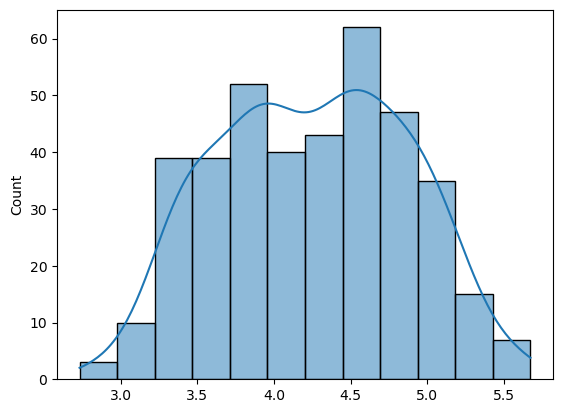

In [51]:
sns.histplot(mpg_transform, kde = True)

In [52]:
X_train, X_test, y_train_transf, y_test_transf = train_test_split(X_norm, mpg_transform, test_size=0.2, random_state = 42)

In [53]:
ridge_regr_model = Ridge(alpha=1)
ridge_regr_model.fit(X_train, y_train_transf)

y_predicted = ridge_regr_model.predict(X_test)
y_estimated = ridge_regr_model.predict(X_train)

print('Train r2 =', ridge_regr_model.score(X_train, y_train_transf))
print('Test r2 =', ridge_regr_model.score(X_test, y_test_transf))

print('MAE_test =', mean_absolute_error(y_test_transf, y_predicted))
print('RMSE_test =', root_mean_squared_error(y_test_transf, y_predicted))

print('MAE_train =', mean_absolute_error(y_train_transf, y_estimated))
print('RMSE_train =', root_mean_squared_error(y_train_transf, y_estimated))

print(ridge_regr_model.coef_)

Train r2 = 0.9813085066400301
Test r2 = 0.9791687599516212
MAE_test = 0.060623130705539374
RMSE_test = 0.08277428359444378
MAE_train = 0.0622152099918098
RMSE_train = 0.08504441299487153
[ 1.78102668 -0.12472853 -0.04848388 -0.23268909 -0.41632558 -0.0655085
  0.23849181 -0.00285974 -0.04009579]


In [55]:
cross_val_results(X_norm, mpg_transform, model = Ridge(alpha=1), cv=5, scoring = 'r2')

Scores: [0.95306308 0.96110411 0.97234858 0.97260104 0.95296856]
Mean: 0.962417075441706
Std: 0.008727466899236445


array([0.95306308, 0.96110411, 0.97234858, 0.97260104, 0.95296856])

In [62]:
lasso_model = Lasso(alpha=1) # use Lasso model - penalises magnitude of coefficients. alpha = 30 is "Large", so penalises relatively agressively
lasso_model.fit(X_train, y_train_transf)

y_predicted = lasso_model.predict(X_test)
y_estimated = lasso_model.predict(X_train)

print('Train r2 =', lasso_model.score(X_train, y_train_transf))
print('Test r2 =', lasso_model.score(X_test, y_test_transf))

print('MAE_test =', mean_absolute_error(y_test_transf, y_predicted))
print('RMSE_test =', root_mean_squared_error(y_test_transf, y_predicted))

print('MAE_train =', mean_absolute_error(y_train_transf, y_estimated))
print('RMSE_train =', root_mean_squared_error(y_train_transf, y_estimated))

print(lasso_model.coef_)

Train r2 = 0.0
Test r2 = -0.006853108446798872
MAE_test = 0.4725030634959539
RMSE_test = 0.5754676655861799
MAE_train = 0.5323891238776634
RMSE_train = 0.6220478415347218
[ 0. -0. -0. -0. -0.  0.  0.  0. -0.]


In [57]:
from scipy.special import inv_boxcox

In [58]:
predictions_original_scale = inv_boxcox(y_predicted, lambda_value)

In [59]:
predictions_original_scale

array([25.60586762, 22.80451009, 36.08102891, 25.02272839, 27.26492329,
       28.09349136, 12.70216711, 26.71346182, 19.09908807, 28.8289476 ,
       14.08962161, 20.10524039, 16.18471121, 28.4991031 , 18.14486125,
       28.06522288, 19.62695778, 32.53720888, 27.05974008, 33.84296891,
       20.19884699, 43.86204993, 34.90620553, 16.40053242, 26.73891071,
       25.52119762, 21.00069677, 16.50592947, 26.51878644, 22.47507303,
       14.6963189 , 20.04891705, 18.66340976, 31.2603144 , 13.48936317,
       38.66852952, 13.95527466, 24.38734445, 13.56761668, 11.17167944,
       13.92531826, 25.02572988, 36.83622891, 26.0048355 , 14.04930678,
       12.57013013, 18.1706754 , 36.73774681, 21.76816205, 29.4823398 ,
       13.8265899 , 23.82159892, 25.65536962, 36.09252767, 22.77345738,
       16.66719407, 18.97658173, 20.00116762, 23.72248542, 24.33586502,
       11.90773691, 21.44598479, 25.31490794, 23.01560799, 23.23006624,
       25.81422349, 24.98454383, 29.18878583, 19.30682957, 13.43